In [1]:
import cooperative_tasep_lib as tasep
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from joblib import Parallel, delayed

In [5]:
L = 300
T = 100
q = 1
kon = 1
koff = 1
kstep = 10
kq = 0.1

In [29]:
def count(nn):
    left = nn[:,0]
    right = nn[:,1]
    nn = np.hstack([left,right])
    x = np.arange(-100, 100, dtype=np.int16)
    counts = [np.sum(nn==i) for i in x ]
    return x, np.array(counts, dtype=np.int32)/len(left)


def main_job(kq, kstep):   
    data, actiation, nn_a, times, res, dts = tasep.ssim(L, 10*T, 0.1, koff, kstep, kq, 1)
    data, actiation, nn_b, times, res, dts = tasep.ssim(L, 10*T, 0.1, koff, kstep, kq, 10)
    data, actiation, nn_c, times, res, dts = tasep.ssim(L, 10*T, 1, koff, kstep, kq, 1)
    x, y_a = count(nn_a)
    x, y_b = count(nn_b)
    x, y_c = count(nn_c)
    return [y_a, y_b, y_c]

In [30]:
KQ = [10, 30, 50, 75, 100]
KSTEP = [10, 30, 50, 75, 100]

In [31]:
res = Parallel(n_jobs = 13)(
    delayed(main_job)(kq,kstep)
    for kq in KQ
    for kstep in KSTEP
)

Text(0.5, 0.98, 'KON = 0.1')

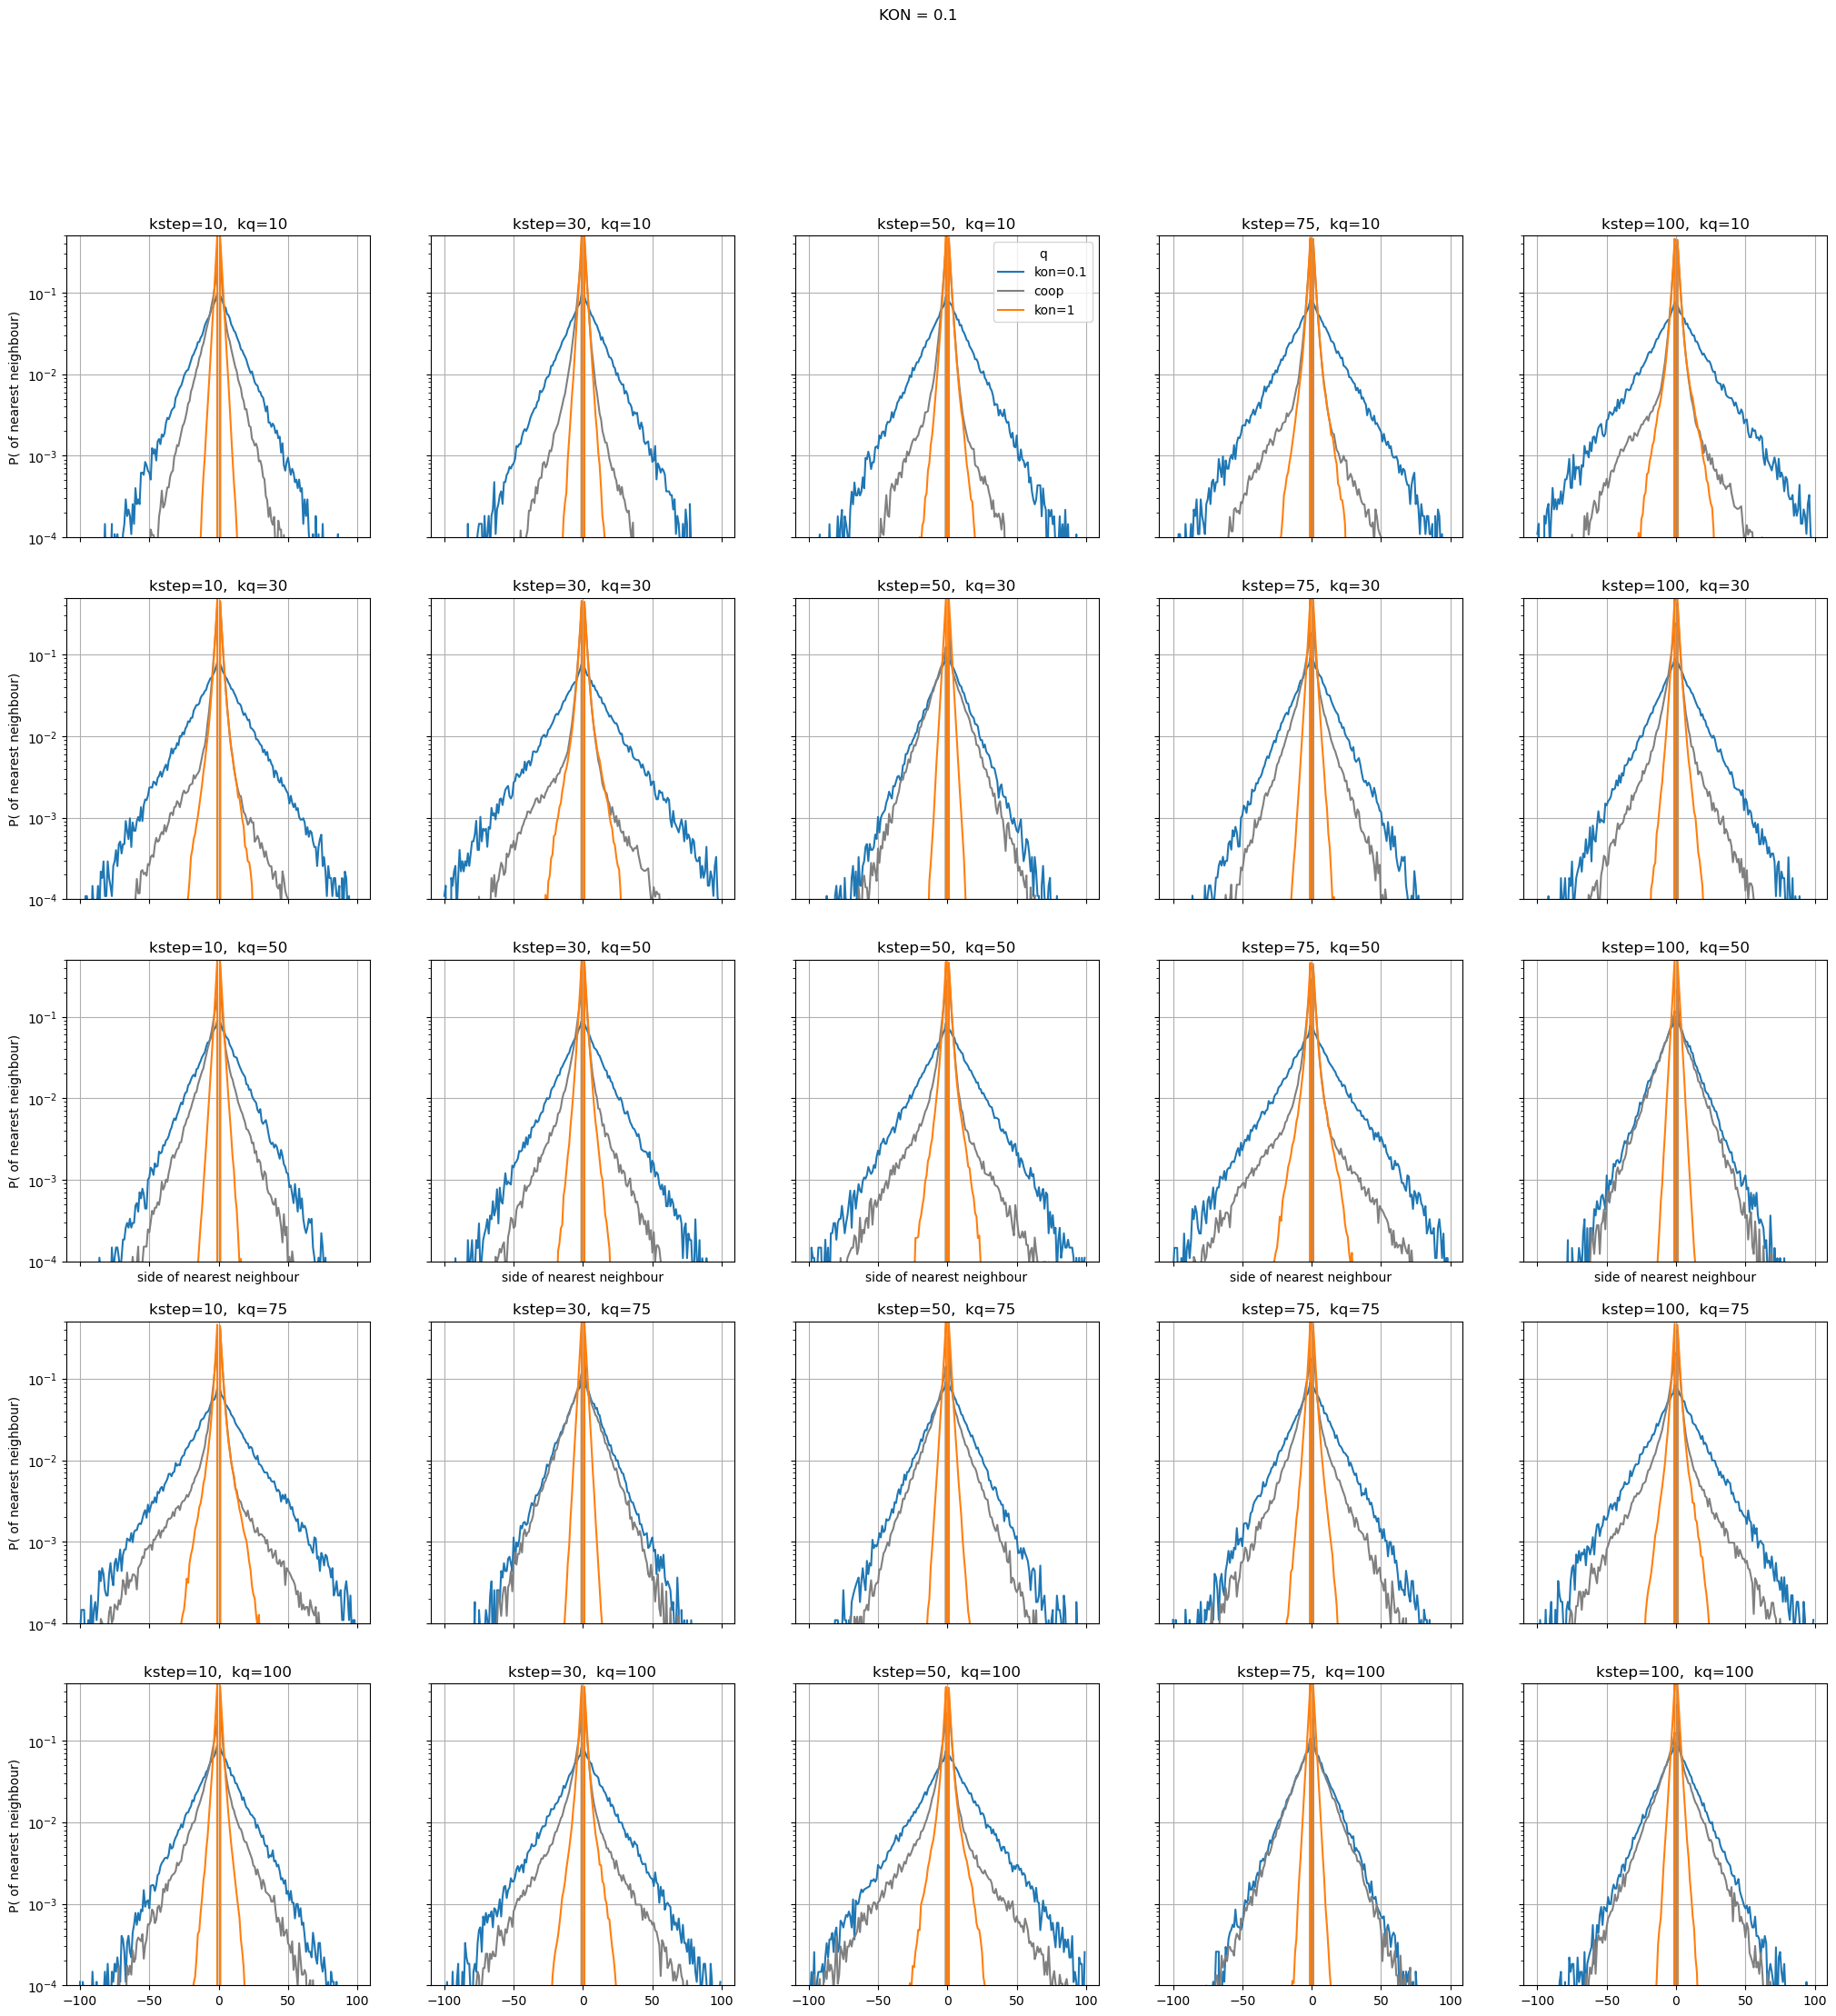

In [39]:
fig, axes = plt.subplots(5,5, figsize=(25,25), sharex=True, sharey=True)
x = np.arange(-100, 100)

for row, kq in enumerate(KQ):
    for col, kstep in enumerate(KSTEP):
        ax = axes[row][col]
        
        ax.plot(x, res[3*row+col][0], label=f"kon=0.1")
        ax.plot(x, res[3*row+col][1], color = "grey", label=f"coop")
        ax.plot(x, res[3*row+col][2], label=f"kon=1")
    
        # ax.plot(x_th, y_th, c="grey", linestyle="-.")
        ax.grid()
        ax.set(title=f"kstep={kstep},  kq={kq}", ylim=[0.0001, 0.5], yscale='log')

        if col==0:
            ax.set(ylabel = "P( of nearest neighbour)")
        if row==2:
            ax.set(xlabel = "side of nearest neighbour")

        if col==2 and row==0:
            ax.legend(title = 'q')

plt.suptitle("KON = 0.1")

In [40]:
fig.savefig("very_dense_b.png", dpi=300)

In [16]:
res[0]

[array([0.02126879, 0.01760176, 0.01833517, 0.01796846, 0.02126879,
        0.02566923, 0.02566923, 0.02603594, 0.02750275, 0.03813715,
        0.03667033, 0.04070407, 0.04840484, 0.05023836, 0.04950495,
        0.06710671, 0.07187385, 0.07444078, 0.07444078, 0.09754309,
        0.        , 0.08947561, 0.08324166, 0.07040704, 0.06270627,
        0.06417308, 0.05720572, 0.0550055 , 0.04180418, 0.04180418,
        0.03593693, 0.03703704, 0.03116978, 0.03557022, 0.02530253,
        0.02456912, 0.02310231, 0.01943528, 0.02053539, 0.01540154,
        0.01540154]),
 array([0.00692349, 0.00781111, 0.00727854, 0.00976389, 0.01047399,
        0.0133144 , 0.01207172, 0.01704243, 0.02112551, 0.02538612,
        0.03053435, 0.03248713, 0.04047577, 0.04526895, 0.05840582,
        0.06461921, 0.07846618, 0.10917806, 0.15941772, 0.21374046,
        0.        , 0.38540742, 0.17397479, 0.10136694, 0.06444168,
        0.04597905, 0.03301971, 0.02467602, 0.02361086, 0.01935026,
        0.01846263, 0.0175